In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [13]:
titanic_data = pd.read_csv('titanic.csv')
print("First 10 rows of Titanic dataset:")
display(titanic_data.head(10))


First 10 rows of Titanic dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [14]:
titanic_data.isnull().sum()

titanic_data['Age'].fillna(titanic_data['Age'].median(), inplace=True)
titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0], inplace=True)
display(titanic_data.isnull().sum())


C:\Users\Shah\AppData\Local\Temp\ipykernel_8104\1578350259.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  titanic_data['Age'].fillna(titanic_data['Age'].median(), inplace=True)
C:\Users\Shah\AppData\Local\Temp\ipykernel_8104\1578350259.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [15]:
age_mean = titanic_data['Age'].mean()
age_median = titanic_data['Age'].median()
age_mode = titanic_data['Age'].mode()[0]
display(f"Mean Age: {age_mean}, Median Age: {age_median}, Mode Age: {age_mode}")

fare_mean = titanic_data['Fare'].mean()
fare_median = titanic_data['Fare'].median()
fare_mode = titanic_data['Fare'].mode()[0]
display(f"Mean Fare: {fare_mean}, Median Fare: {fare_median}, Mode Fare: {fare_mode}")

'Mean Age: 29.69911764705882, Median Age: 28.0, Mode Age: 24.0'

'Mean Fare: 32.204207968574636, Median Fare: 14.4542, Mode Fare: 8.05'

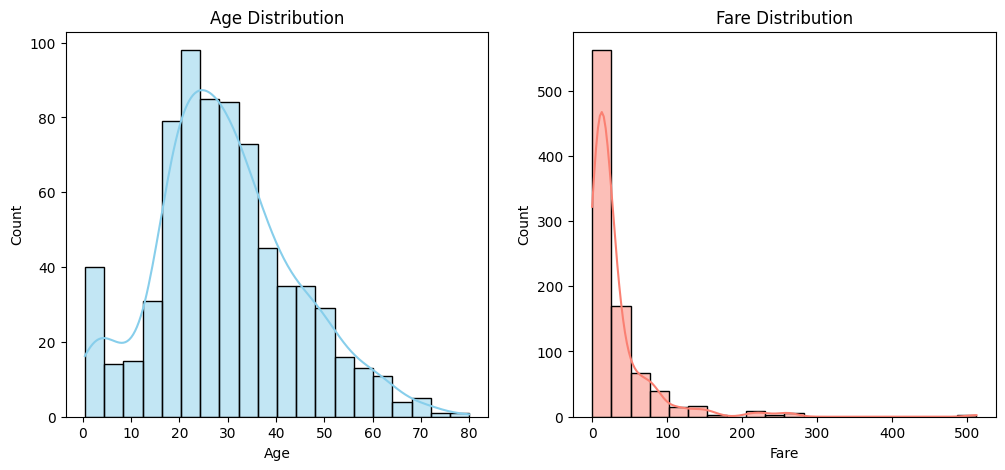

In [16]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(titanic_data['Age'], bins=20, kde=True, color='skyblue')
plt.title('Age Distribution')
plt.subplot(1,2,2)
sns.histplot(titanic_data['Fare'], bins=20, kde=True, color='salmon')
plt.title('Fare Distribution')
plt.show()

In [17]:
le = LabelEncoder()
titanic_data['sex_encoded'] = le.fit_transform(titanic_data['Sex'])

print(titanic_data[['Sex', 'sex_encoded']].head(10))

      Sex  sex_encoded
0    male            1
1  female            0
2  female            0
3  female            0
4    male            1
5    male            1
6    male            1
7    male            1
8  female            0
9  female            0


In [18]:
titanic_data = pd.get_dummies(titanic_data, columns=['Embarked'], drop_first=True)

display(titanic_data.head(10))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,sex_encoded,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,1,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,0,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,0,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,1,False,True
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,1,True,False
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,1,False,True
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,1,False,True
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,0,False,True
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,0,False,False


               Age      Fare    Pclass  Survived
Age       1.000000  0.096067 -0.369226 -0.077221
Fare      0.096067  1.000000 -0.549500  0.257307
Pclass   -0.369226 -0.549500  1.000000 -0.338481
Survived -0.077221  0.257307 -0.338481  1.000000


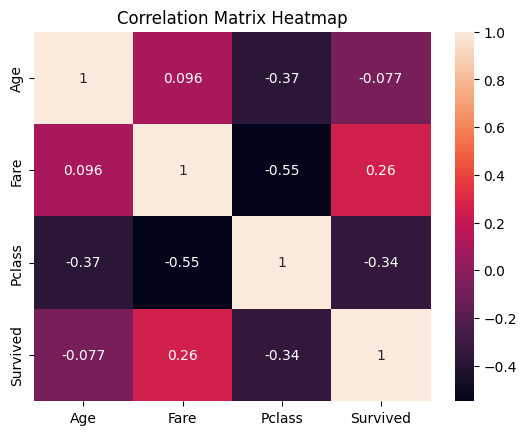

In [19]:
columns = ['Age', 'Fare', 'Pclass', 'Survived']
corr_matrix = titanic_data[columns].corr()
print(corr_matrix)

plt.figure()
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Matrix Heatmap")
plt.show()


      Fare  Fare_scaled
0   7.2500     0.014151
1  71.2833     0.139136
2   7.9250     0.015469
3  53.1000     0.103644
4   8.0500     0.015713


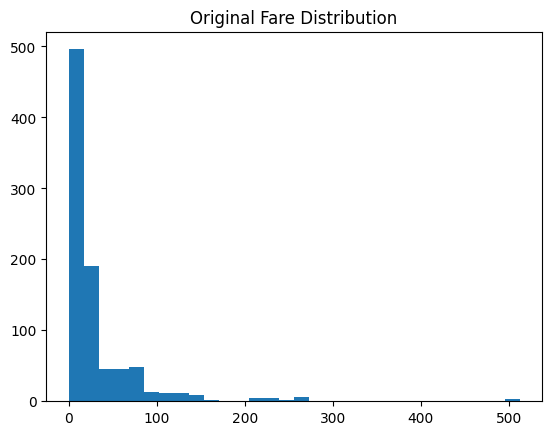

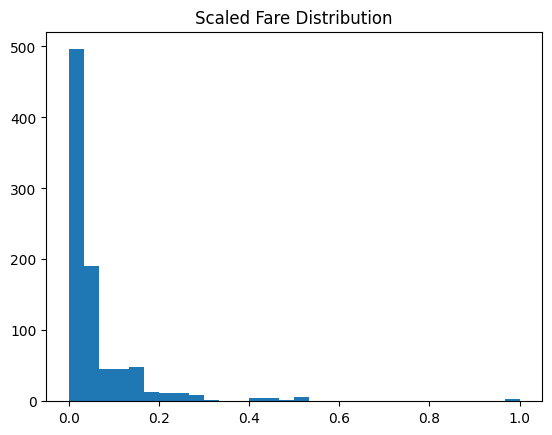

In [20]:
minmax = MinMaxScaler()
titanic_data['Fare_scaled'] = minmax.fit_transform(titanic_data[['Fare']])
print(titanic_data[['Fare', 'Fare_scaled']].head())

plt.figure()
plt.hist(titanic_data['Fare'].dropna(), bins=30)
plt.title("Original Fare Distribution")
plt.show()

plt.figure()
plt.hist(titanic_data['Fare_scaled'].dropna(), bins=30)
plt.title("Scaled Fare Distribution")
plt.show()

2.2329064647904385e-16
1.0005616400330457


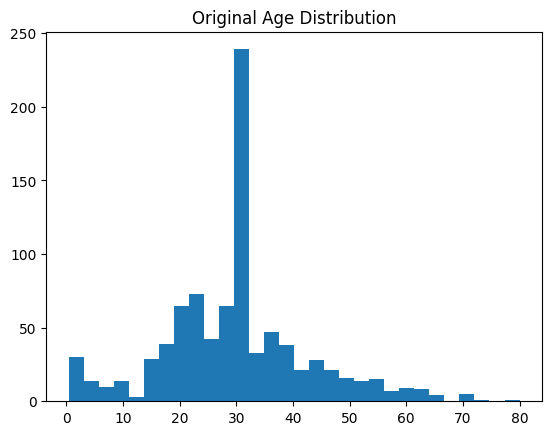

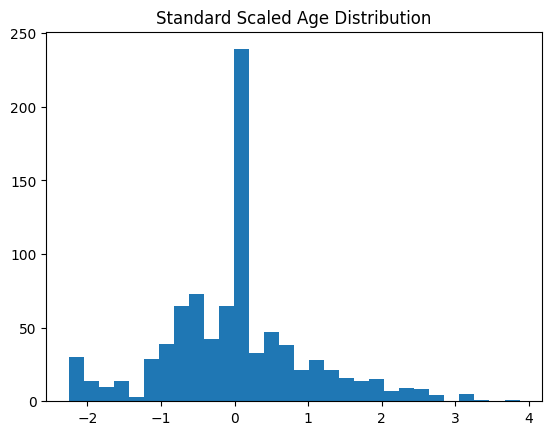

In [21]:
titanic_data['Age'] = titanic_data['Age'].fillna(titanic_data['Age'].mean())
std_scaler = StandardScaler()
titanic_data['Age_scaled'] = std_scaler.fit_transform(titanic_data[['Age']])

print(titanic_data['Age_scaled'].mean())
print(titanic_data['Age_scaled'].std())

plt.figure()
plt.hist(titanic_data['Age'], bins=30)
plt.title("Original Age Distribution")
plt.show()

plt.figure()
plt.hist(titanic_data['Age_scaled'], bins=30)
plt.title("Standard Scaled Age Distribution")
plt.show()